<h3 align="right" style="color: #ff6b35">واردات کتابخانه ها</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import joblib
from hazm import Normalizer, WordTokenizer
from gensim.models import FastText, Word2Vec
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

<h3 align="right" style="color: #ff6b35">بارگذاری دیتاست (آموزشی)</h3>

In [31]:
df = pd.read_parquet("./data/sentiment_dksf_train.parquet")

In [32]:
print("ستون‌های دیتاست :", df.columns.tolist())

ستون‌های دیتاست : ['text', 'label']


In [33]:
print("توزیع کلاس های ستون\n", df['label'].value_counts())

توزیع کلاس های ستون
 label
0    10206
1     9587
2     8809
Name: count, dtype: int64


In [34]:
print("تعداد نمونه‌ها :", len(df))

تعداد نمونه‌ها : 28602


In [35]:
print("نمونه‌های اولیه :")
display(df.head(5))

نمونه‌های اولیه :


,text,label
0,شیشه هاش همون روز اول شکست,0
1,تمیز -مرتب- چقدر پیک آن تایم و مؤدب …سپاس بسیا...,1
2,نظر من هیچ گاه این محصول رو خریداری نکنید اگه ...,0
3,برنج ایرانی سفارش دادم افتضاح بود با هندی هیچ ...,0
4,سلام اصلا راضی نیستم یعنی ارزش خرید نداره,0


<h3 align="right" style="color: #ff6b35">آمار متن قبل از پیش پردازش</h3>

In [36]:
def text_stats(df, text_col='text'):
    lengths_char = df[text_col].str.len()
    lengths_word = df[text_col].apply(lambda x: len(x.split()))
    unique_words = len(set(' '.join(df[text_col].astype(str)).split()))
    
    print(f"میانگین طول متن (کاراکتر) : {lengths_char.mean():.2f}")
    print(f"میانگین طول متن (کلمه) : {lengths_word.mean():.2f}")
    print(f"تعداد کلمات منحصربه‌فرد : {unique_words}")

print("آمار متن قبل از پیش پردازش :")
text_stats(df)

آمار متن قبل از پیش پردازش :
میانگین طول متن (کاراکتر) : 125.53
میانگین طول متن (کلمه) : 25.77
تعداد کلمات منحصربه‌فرد : 58975


<h3 align="right" style="color: #ff6b35">پیش پردازش متن</h3>

In [37]:
normalizer = Normalizer()

tokenizer = WordTokenizer()

custom_stopwords = {
    # حروف اضافه و ربط خیلی رایج
    'از', 'به', 'در', 'با', 'برای', 'تا', 'را', 'و', 'که', 'این', 'اون', 'آن', 'های', 'ها', 'ای', 'ام', 'ات', 'اش', 'شان', 'تان', 'مان',

    # افعال کمکی و بودن/شدن
    'است', 'بود', 'بودم', 'بودی', 'بودیم', 'بودند', 'هست', 'هستم', 'هستی', 'هستیم', 'هستند', 'شد', 'شدم', 'شدی', 'شدیم', 'شدند',

    # کلمات خیلی عمومی بدون بار احساسی قوی
    'می', 'میشه', 'میتونه', 'میتونم', 'میتونی', 'میکنه', 'میکنم', 'میکنی', 'میکنیم', 'میکنن',
    'یه', 'ی', 'هم', 'نیز', 'یا', 'ولی', 'اما', 'اگر', 'تا', 'پس', 'چون', 'هر', 'همه', 'هیچ', 'چند', 'بسیار', 'خیلی', 'کمی',

    # ضمایر و کلمات اشاره‌ای خیلی رایج
    'من', 'تو', 'او', 'ما', 'شما', 'ایشان', 'خود', 'خودم', 'خودت', 'خودش', 'خودمون', 'خودتون',

    # برخی کلمات ساختاری
    'بودن', 'شدن', 'کردن', 'داشتن', 'داشتم', 'داشتی', 'داشتیم', 'داشتند'
}

stopwords = custom_stopwords

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s\u0600-\u06FF]', '', text)
    text = normalizer.normalize(text)
    text = text.replace('\u200c', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text(text):
    cleaned = clean_text(text)
    if not cleaned:
        return []
    tokens = tokenizer.tokenize(cleaned)
    tokens = [
        t for t in tokens
        if t not in stopwords
        and len(t) > 1
        and not t.isdigit()
    ]
    return tokens

In [38]:
print("...در حال پیش پردازش متن‌ها (ممکن است چند دقیقه طول بکشه)")
df['clean_text'] = df['text'].apply(clean_text)
df['tokens'] = df['clean_text'].apply(preprocess_text)
df['clean_text_joined'] = df['tokens'].apply(lambda x: ' '.join(x) if x else '')

...در حال پیش پردازش متن‌ها (ممکن است چند دقیقه طول بکشه)


<h3 align="right" style="color: #ff6b35">آمار متن بعد از پیش پردازش</h3>

In [39]:
print("آمار متن بعد از پیش پردازش :")
text_stats(df, text_col='clean_text_joined')

آمار متن بعد از پیش پردازش :
میانگین طول متن (کاراکتر) : 98.21
میانگین طول متن (کلمه) : 18.31
تعداد کلمات منحصربه‌فرد : 43449


In [40]:
print("نمونه های قبل و بعد پیش پردازش :")

df_display = df[['text', 'clean_text', 'tokens']].head(5).copy()
df_display['tokens'] = df_display['tokens'].apply(lambda x: x[:15] if isinstance(x, (list, tuple)) else x)

df_display = df_display.rename(columns={
    'text': 'متن خام',
    'clean_text': 'متن تمیز شده',
    'tokens': 'توکن‌ها (15 تای اول)'
})

display(df_display.style.hide(axis='index'))

نمونه های قبل و بعد پیش پردازش :


متن خام,متن تمیز شده,توکن‌ها (15 تای اول)
شیشه هاش همون روز اول شکست,شیشه هاش همون روز اول شکست,"['شیشه', 'هاش', 'همون', 'روز', 'اول', 'شکست']"
تمیز -مرتب- چقدر پیک آن تایم و مؤدب …سپاس بسیار عالی فقط کاشکی رنگ دستمال همونی می‌بود که در شکل انتخاب کردیم … باز هم سپاس بسیار عالی از سرعت و کیفیت,تمیز مرتب چقدر پیک آن تایم و مؤدب سپاس بسیار عالی فقط کاشکی رنگ دستمال همونی می بود که در شکل انتخاب کردیم باز هم سپاس بسیار عالی از سرعت و کیفیت,"['تمیز', 'مرتب', 'چقدر', 'پیک', 'تایم', 'مؤدب', 'سپاس', 'عالی', 'فقط', 'کاشکی', 'رنگ', 'دستمال', 'همونی', 'شکل', 'انتخاب']"
نظر من هیچ گاه این محصول رو خریداری نکنید اگه می خواهید شانستون رو امتحان کنین ببینین کارت هاتون 108 تا یا 52 هستش راه باز هست بعضی ها میگن 108 کارت داره بعضی ها هم میگن 54 تا کارت داره در اصل این محصول باید 108 کارت باشه که برای من 52 تا دراومد و فارسی هم هستش و برای یک کالای دیگه هستش که قیمتش ارزونتره,نظر من هیچ گاه این محصول رو خریداری نکنید اگه می خواهید شانستون رو امتحان کنین ببینین کارت هاتون ۱۰۸ تا یا ۵۲ هستش راه باز هست بعضی ها میگن ۱۰۸ کارت داره بعضی ها هم میگن ۵۴ تا کارت داره در اصل این محصول باید ۱۰۸ کارت باشه که برای من ۵۲ تا دراومد و فارسی هم هستش و برای یک کالای دیگه هستش که قیمتش ارزونتره,"['نظر', 'گاه', 'محصول', 'رو', 'خریداری', 'نکنید', 'اگه', 'خواهید_شانستون', 'رو', 'امتحان', 'کنین', 'ببینین', 'کارت', 'هاتون', 'هستش']"
برنج ایرانی سفارش دادم افتضاح بود با هندی هیچ فرقی نمیکرد,برنج ایرانی سفارش دادم افتضاح بود با هندی هیچ فرقی نمی کرد,"['برنج', 'ایرانی', 'سفارش', 'دادم', 'افتضاح', 'هندی', 'فرقی', 'نمی', 'کرد']"
سلام اصلا راضی نیستم یعنی ارزش خرید نداره,سلام اصلا راضی نیستم یعنی ارزش خرید نداره,"['سلام', 'اصلا', 'راضی', 'نیستم', 'یعنی', 'ارزش', 'خرید', 'نداره']"


<h3 align="right" style="color: #ff6b35">NaN بررسی تعداد داده های</h3>

In [41]:
print("clean_text_joined در NaN تعداد :\n", df['clean_text_joined'].isna().sum())
print("\nتعداد رشته خالی ('') :", (df['clean_text_joined'] == '').sum())

problematic = df[df['clean_text_joined'].isna() | (df['clean_text_joined'] == '')]

print("\nنمونه ردیف‌های مشکل‌دار (5 مورد اول) :")
df_problem = problematic[['text', 'clean_text', 'clean_text_joined']].head(5)
df_problem = df_problem.rename(columns={
        'text': 'متن اصلی',
        'clean_text': 'متن تمیز شده',
        'clean_text_joined': '(joined) متن نهایی'
})

display(df_problem)

print("\nتعداد کل ردیف‌های مشکل‌دار :", len(problematic))

clean_text_joined در NaN تعداد :
 0

تعداد رشته خالی ('') : 161

نمونه ردیف‌های مشکل‌دار (5 مورد اول) :


,متن اصلی,متن تمیز شده,(joined) متن نهایی
79,.............,,
255,۴و ۳,۴ و ۳,
360,۲٫ ۳٫۸,۲ ٫ ۳ ٫ ۸,
490,و۲و۸,و ۲ و ۸,
775,--,,



تعداد کل ردیف‌های مشکل‌دار : 161


<h3 align="right" style="color: #ff6b35">NaN حذف داده های</h3>

In [42]:
print("قبل از حذف :")
print("NaN تعداد :", df['clean_text_joined'].isna().sum())
print("تعداد کل نمونه‌ها قبل :", len(df))

df['clean_text_joined'] = df['clean_text_joined'].fillna('')
df['clean_text_joined'] = df['clean_text_joined'].astype(str)
df = df[df['clean_text_joined'].str.strip() != ''].reset_index(drop=True)

print("\nبعد از حذف :")
print("تعداد نمونه باقی‌مانده :", len(df))
print("NaN تعداد :", df['clean_text_joined'].isna().sum())

print("\nبررسی نهایی :")
print("تعداد رشته خالی باقی‌مانده :", (df['clean_text_joined'] == '').sum())
print("strip حداقل طول متن بعد از :\n", df['clean_text_joined'].str.strip().str.len().min())

print("\nclean_text_joined نوع داده :")
print(df['clean_text_joined'].apply(type).value_counts())

قبل از حذف :
NaN تعداد : 0
تعداد کل نمونه‌ها قبل : 28602

بعد از حذف :
تعداد نمونه باقی‌مانده : 28441
NaN تعداد : 0

بررسی نهایی :
تعداد رشته خالی باقی‌مانده : 0
strip حداقل طول متن بعد از :
 2

clean_text_joined نوع داده :
clean_text_joined
<class 'str'>    28441
Name: count, dtype: int64


In [43]:
df.to_csv("./data/sentiment_processed_train.csv", index=False, encoding='utf-8-sig')
print(".انجام شد sentiment_processed_train.csv ذخیره")

.انجام شد sentiment_processed_train.csv ذخیره


In [2]:
df = pd.read_csv("./data/sentiment_processed_train.csv")

In [45]:
print("ستون‌ها :", df.columns.tolist())

ستون‌ها : ['text', 'label', 'clean_text', 'tokens', 'clean_text_joined']


<h3 align="right" style="color: #ff6b35">نمایش متن</h3>

<div align="center">TF-IDF</div>

<h3 align="right" style="color: #ff6b35">تصمیم گیری برای بررسی تعداد ویژگی ها</h3>

In [17]:
for mf in [5000, 10000, 15000, None]:
    print(f"\n--- max_features = {mf} ---")
    vec = TfidfVectorizer(max_features=mf, min_df=2, analyzer='word')
    emb = vec.fit_transform(df['clean_text_joined'])
    vocab_size = len(vec.vocabulary_)
    all_unique = len(set(' '.join(df['clean_text_joined']).split()))
    coverage = vocab_size / all_unique * 100 if all_unique else 0
    print(f"ویژگی‌ها: {vocab_size:,} | پوشش: %{coverage:.2f}")
    print(f"ابعاد: {emb.shape}")


--- max_features = 5000 ---
ویژگی‌ها: 5,000 | پوشش: %11.51
ابعاد: (28441, 5000)

--- max_features = 10000 ---
ویژگی‌ها: 10,000 | پوشش: %23.02
ابعاد: (28441, 10000)

--- max_features = 15000 ---
ویژگی‌ها: 15,000 | پوشش: %34.52
ابعاد: (28441, 15000)

--- max_features = None ---
ویژگی‌ها: 16,307 | پوشش: %37.53
ابعاد: (28441, 16307)


In [28]:
vectorizer = TfidfVectorizer(max_features=15000, min_df=2, analyzer='word')
tfidf_embeddings = vectorizer.fit_transform(df['clean_text_joined'])

In [29]:
joblib.dump(vectorizer, r"./data/tfidf_vectorizer.pkl")
print(".فیت و ذخیره شد train روی Vectorizer")

.فیت و ذخیره شد train روی Vectorizer


In [16]:
vectorizer = joblib.load(r".\data\tfidf_vectorizer.pkl")
print(".لود شد Vectorizer")

.لود شد Vectorizer


In [30]:
print("TF-IDF Embeddings :")
print(f"ابعاد ماتریس : {tfidf_embeddings.shape}")
print(f"تعداد واژگان پوشش داده‌شده : {len(vectorizer.vocabulary_)}")
print("برای 10 متن اول embedding نمونه :")
print(tfidf_embeddings[0].toarray()[0][:10])

all_words = ' '.join(df['clean_text_joined']).split()
unique_words = set(all_words)
tfidf_coverage = len(vectorizer.vocabulary_) / len(unique_words) * 100 if unique_words else 0
print(f"پوشش واژگان : %{tfidf_coverage:.2f}")

TF-IDF Embeddings :
ابعاد ماتریس : (28441, 15000)
تعداد واژگان پوشش داده‌شده : 15000
برای 10 متن اول embedding نمونه :
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
پوشش واژگان : %34.52


In [19]:
np.save(r"D:\data-Project-NLP\tfidf_embeddings.npy", tfidf_embeddings.toarray())
print("\n.انجام شد tfidf_embeddings.npy ذخیره")


.انجام شد tfidf_embeddings.npy ذخیره


In [3]:
tfidf_embeddings = np.load(r"D:\data-Project-NLP\tfidf_embeddings.npy")

<div align="center">Fast Text</div>

In [21]:
sentences = df['tokens'].tolist()

fasttext_model = FastText(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=5,
    epochs=20,
    sg=1,
    workers=4
)

def get_fasttext_embedding(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

fasttext_embeddings = np.array([get_fasttext_embedding(tokens, fasttext_model) for tokens in df['tokens']])

print("FastText Embeddings :")
print(f"ابعاد هر بردار : {fasttext_model.vector_size}")
print(f"ابعاد ماتریس : {fasttext_embeddings.shape}")
print(f"تعداد واژگان پوشش داده‌شده : {len(fasttext_model.wv)}")
print("برای متن اول embedding نمونه :")
print(fasttext_embeddings[0][:10])

fasttext_coverage = len(fasttext_model.wv) / len(unique_words) * 100 if unique_words else 0
print(f"پوشش واژگان : %{fasttext_coverage:.2f}")

FastText Embeddings :
ابعاد هر بردار : 300
ابعاد ماتریس : (28441, 300)
تعداد واژگان پوشش داده‌شده : 104
برای متن اول embedding نمونه :
[ 0.02743842  0.00723743 -0.00403445 -0.00122524 -0.02884895 -0.01821702
  0.01248218  0.00263962 -0.0028816   0.02043389]
پوشش واژگان : %0.24


In [22]:
sentences = df['tokens'].tolist()

fasttext_model = FastText(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=2,
    epochs=25,
    sg=1,
    workers=4
)

def get_fasttext_embedding(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

fasttext_embeddings = np.array([get_fasttext_embedding(tokens, fasttext_model) for tokens in df['tokens']])

print("FastText Embeddings :")
print(f"ابعاد هر بردار : {fasttext_model.vector_size}")
print(f"ابعاد ماتریس : {fasttext_embeddings.shape}")
print(f"تعداد واژگان پوشش داده‌شده : {len(fasttext_model.wv)}")
print("برای متن اول embedding نمونه :")
print(fasttext_embeddings[0][:10])

fasttext_coverage = len(fasttext_model.wv) / len(unique_words) * 100 if unique_words else 0
print(f"پوشش واژگان : %{fasttext_coverage:.2f}")

FastText Embeddings :
ابعاد هر بردار : 300
ابعاد ماتریس : (28441, 300)
تعداد واژگان پوشش داده‌شده : 107
برای متن اول embedding نمونه :
[ 0.04484306  0.00432509 -0.01446144 -0.01642148  0.02709966 -0.03784044
  0.03254221  0.04056868  0.00640705  0.04165835]
پوشش واژگان : %0.25


In [23]:
np.save(r"D:\data-Project-NLP\fasttext_embeddings.npy", fasttext_embeddings)
print("\n.انجام شد fasttext_embeddings.npy ذخیره")


.انجام شد fasttext_embeddings.npy ذخیره


In [4]:
fasttext_embeddings = np.load(r"D:\data-Project-NLP\fasttext_embeddings.npy")

<div align="center">Word2Vec</div>

In [29]:
sentences = df['tokens'].tolist()

word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=3,
    epochs=25,
    sg=1,
    workers=4,
    negative=5
)

def get_word2vec_embedding(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

word2vec_embeddings = np.array([
    get_word2vec_embedding(tokens, word2vec_model) 
    for tokens in df['tokens']
])

print("Word2Vec Embeddings :")
print(f"ابعاد هر بردار : {word2vec_model.vector_size}")
print("embeddings ابعاد ماتریس :")
print(word2vec_embeddings.shape)
print(f"تعداد واژگان مدل : {len(word2vec_model.wv):,}")

all_unique_words = len(set(' '.join(df['clean_text_joined']).split()))
coverage = len(word2vec_model.wv) / all_unique_words * 100 if all_unique_words > 0 else 0
print(f"پوشش واژگان تقریبی : %{coverage:.2f}")

print("متن اول (۱۰ بعد اول) embedding نمونه :")
print(word2vec_embeddings[0][:10])

Word2Vec Embeddings :
ابعاد هر بردار : 300
embeddings ابعاد ماتریس :
(28441, 300)
تعداد واژگان مدل : 106
پوشش واژگان تقریبی : %0.24
متن اول (۱۰ بعد اول) embedding نمونه :
[-0.00152851 -0.02327841 -0.03634987  0.05699404  0.101305   -0.03872554
  0.07237802  0.01871239 -0.0081173   0.03536129]


In [27]:
np.save(r"D:\data-Project-NLP\word2vec_embeddings.npy", word2vec_embeddings)
print("\n.انجام شد word2vec_embeddings.npy ذخیره")


.انجام شد word2vec_embeddings.npy ذخیره


In [5]:
word2vec_embeddings = np.load(r"D:\data-Project-NLP\word2vec_embeddings.npy")

<div align="center">ParsBERT</div>

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"استفاده از دستگاه : {device}")

استفاده از دستگاه : cpu


In [71]:
model_name = "HooshvareLab/bert-fa-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

def get_parsbert_batch(texts, batch_size=16, max_length=128):
    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                max_length=max_length,
                truncation=True,
                padding=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings.append(batch_emb)
            print(f"Batch {i//batch_size + 1} از {len(texts)//batch_size + 1} پردازش شد")
    return np.vstack(embeddings)

In [72]:
texts = df['clean_text_joined'].tolist()
print(f"\nتعداد متن‌ها : {len(texts)}")


تعداد متن‌ها : 28441


In [ ]:
print("...(ممکن است چند دقیقه طول بکشد) ParsBERT embeddings در حال محاسبه")
parsbert_embeddings = get_parsbert_batch(texts, batch_size=16)

In [8]:
print("\nParsBERT Embeddings :")
print(f"ابعاد هر  بردار : {parsbert_embeddings.shape[1]}")
print(f"ابعاد ماتریس : {parsbert_embeddings.shape}")
print("tokenizer اندازه واژگان :")
print(len(tokenizer.vocab))
print("برای متن اول embedding نمونه :")
print(parsbert_embeddings[0][:10])

coverage_pb = 100.0
print(f"پوشش واژگان تقریبی : %{coverage_pb:.2f}")


ParsBERT Embeddings :
ابعاد هر  بردار : 768
ابعاد ماتریس : (28441, 768)
tokenizer اندازه واژگان :
100000
برای متن اول embedding نمونه :
[-0.73025995 -0.6393268   0.874952    0.7822463  -0.38307515  0.15943953
  0.3324342  -0.09210033 -0.78532374 -0.4064703 ]
پوشش واژگان تقریبی : %100.00


In [9]:
np.save(r"D:\data-Project-NLP\parsbert_embeddings.npy", parsbert_embeddings)
print("\n.انجام شد parsbert_embeddings.npy ذخیره")


.انجام شد parsbert_embeddings.npy ذخیره


In [6]:
parsbert_embeddings = np.load(r"D:\data-Project-NLP\parsbert_embeddings.npy")

<h3 align="right" style="color: #ff6b35">مقایسه روش ها</h3>

In [22]:
def compute_similarity(emb1, emb2):
    emb1 = np.asarray(emb1).flatten()
    emb2 = np.asarray(emb2).flatten()
    return cosine_similarity([emb1], [emb2])[0][0]

sim_tfidf    = compute_similarity(tfidf_embeddings[0], tfidf_embeddings[1])
sim_word2vec = compute_similarity(word2vec_embeddings[0], word2vec_embeddings[1])
sim_fasttext = compute_similarity(fasttext_embeddings[0], fasttext_embeddings[1])
sim_parsbert = compute_similarity(parsbert_embeddings[0], parsbert_embeddings[1])

all_unique_words = len(set(' '.join(df['clean_text_joined']).split())) if 'df' in globals() else 1

tfidf_cov   = len(vectorizer.vocabulary_) / all_unique_words * 100 if 'vectorizer' in globals() else 34.05
word2vec_cov = (len(word2vec_model.wv) / all_unique_words * 100 
                if 'word2vec_model' in globals() and len(word2vec_model.wv) > 0 else 0.24)
fasttext_cov = fasttext_coverage if 'fasttext_coverage' in globals() else 0.25
parsbert_cov = 100.0

comparison = pd.DataFrame({
    "روش": ["TF-IDF", "Word2Vec", "FastText", "ParsBERT"],
    
    "ابعاد بردار": [
        tfidf_embeddings.shape[1],
        word2vec_embeddings.shape[1],
        fasttext_embeddings.shape[1],
        parsbert_embeddings.shape[1]
    ],
    
    "درصد پوشش واژگان تقریبی": [
        tfidf_cov,
        word2vec_cov,
        fasttext_cov,
        parsbert_cov
    ],
    
    "پارامترهای کلیدی": [
        "max_features=15000, min_df=2, analyzer='word'",
        "vector_size=300, window=5, min_count=3, epochs=25, sg=1, negative=5",
        "vector_size=300, window=5, min_count=2~5, epochs=20~25, sg=1",
        "hidden_size=768, layers=12, mean pooling, max_length=128"
    ],
    
    "شباهت متن ۰ در مقابل متن ۱": [
        sim_tfidf,
        sim_word2vec,
        sim_fasttext,
        sim_parsbert
    ]
})

print("\n(Embedding) مقایسه روش‌های نمایش متن :")
display(comparison)

print("\nجدول مرتب‌شده بر اساس پوشش واژگان (نزولی) :")
display(comparison.sort_values("درصد پوشش واژگان تقریبی", ascending=False))


(Embedding) مقایسه روش‌های نمایش متن :


,روش,ابعاد بردار,درصد پوشش واژگان تقریبی,پارامترهای کلیدی,شباهت متن ۰ در مقابل متن ۱
0,TF-IDF,15000,34.05,"max_features=15000, min_df=2, analyzer='word'",0.000000
1,Word2Vec,300,0.24,"vector_size=300, window=5, min_count=3, epochs...",0.993856
2,FastText,300,0.25,"vector_size=300, window=5, min_count=2~5, epoc...",0.987243
3,ParsBERT,768,100.00,"hidden_size=768, layers=12, mean pooling, max_...",0.631646



جدول مرتب‌شده بر اساس پوشش واژگان (نزولی) :


,روش,ابعاد بردار,درصد پوشش واژگان تقریبی,پارامترهای کلیدی,شباهت متن ۰ در مقابل متن ۱
3,ParsBERT,768,100.00,"hidden_size=768, layers=12, mean pooling, max_...",0.631646
0,TF-IDF,15000,34.05,"max_features=15000, min_df=2, analyzer='word'",0.000000
2,FastText,300,0.25,"vector_size=300, window=5, min_count=2~5, epoc...",0.987243
1,Word2Vec,300,0.24,"vector_size=300, window=5, min_count=3, epochs...",0.993856


<h3 align="right" style="color: #ff6b35">بارگذاری دیتاست (تستی)</h3>

In [62]:
df_test = pd.read_parquet("./data/sentiment_dksf_test.parquet")

In [63]:
print("داده تست لود شد")
print("تعداد ردیف‌ها :", len(df_test))
print("ستون‌ها :", df_test.columns.tolist())
print("\nنمونه 5 ردیف اول :")
display(df_test[['text', 'label']].head(5))

داده تست لود شد
تعداد ردیف‌ها : 2315
ستون‌ها : ['text', 'label']

نمونه 5 ردیف اول :


,text,label
0,عطره و بیشتر به درد لباس میخوره، چون اصلا پخش ...,0
1,اصلا بدرد نمیخوره.بعد از دو سه روز کنده میشه.ز...,0
2,غذا بسیار با کیفیت بود اما متاسفانه دوتا سفارش...,1
3,غذا خیلی خوب بود، خیلی سریع رسید و قیمتشم خیلی...,1
4,قیمت رو بالا ببرید کیفیت رو کم نکنید لطفا,1


<h3 align="right" style="color: #ff6b35">انجام مراحل پیش پردازش روی داده های تست</h3>

In [64]:
df_test['clean_text'] = df_test['text'].apply(clean_text)
df_test['tokens'] = df_test['clean_text'].apply(preprocess_text)
df_test['clean_text_joined'] = df_test['tokens'].apply(lambda x: ' '.join(x) if x else '')

df_test = df_test[df_test['clean_text_joined'].str.strip() != ''].reset_index(drop=True)

print("داده تست بعد از پیش پردازش :")
print("تعداد ردیف‌ها :", len(df_test))
print("clean_text_joined در NaN تعداد :\n", df_test['clean_text_joined'].isna().sum())
print("تعداد خالی :", (df_test['clean_text_joined'] == '').sum())

داده تست بعد از پیش پردازش :
تعداد ردیف‌ها : 2312
clean_text_joined در NaN تعداد :
 0
تعداد خالی : 0


In [76]:
df_test.to_csv("./data/sentiment_processed_test.csv", index=False, encoding='utf-8-sig')
print(".انجام شد sentiment_processed_test.csv ذخیره")

.انجام شد sentiment_processed_test.csv ذخیره


In [7]:
df_test = pd.read_csv("./data/sentiment_processed_test.csv")

In [66]:
print("ستون‌ها :", df_test.columns.tolist())

ستون‌ها : ['text', 'label', 'clean_text', 'tokens', 'clean_text_joined']


<h3 align="right" style="color: #ff6b35">انجام مراحل نمایش متن روی داده های تست</h3>

<div align="center">TF-IDF for Test data</div>

In [68]:
X_tfidf_test = vectorizer.transform(df_test['clean_text_joined'])
print(": تست ساخته شد. ابعاد TF-IDF\n", X_tfidf_test.shape)

: تست ساخته شد. ابعاد TF-IDF
 (2312, 15000)


In [83]:
np.save(r"D:\data-Project-NLP\X_tfidf_test.npy", X_tfidf_test.toarray())
print("\n.انجام شد X_tfidf_test.npy ذخیره")


.انجام شد X_tfidf_test.npy ذخیره


In [8]:
X_tfidf_test = np.load(r"D:\data-Project-NLP\X_tfidf_test.npy")

<div align="center">ParsBERT for Test data</div>

In [ ]:
texts_test = df_test['clean_text_joined'].tolist()
parsbert_embeddings_test = get_parsbert_batch(texts_test, batch_size=16)

In [74]:
print(": تست ساخته شد. ابعاد ParsBERT\n", parsbert_embeddings_test.shape)

: تست ساخته شد. ابعاد ParsBERT
 (2312, 768)


In [84]:
np.save(r"D:\data-Project-NLP\parsbert_embeddings_test.npy", parsbert_embeddings_test)
print("\n.انجام شد parsbert_embeddings_test.npy ذخیره")


.انجام شد parsbert_embeddings_test.npy ذخیره


In [9]:
parsbert_embeddings_test = np.load(r"D:\data-Project-NLP\parsbert_embeddings_test.npy")

<h3 align="right" style="color: #ff6b35">مقایسه عملکرد روی داده تست</h3>

In [10]:
y_train = df['label'].values
y_test  = df_test['label'].values

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(tfidf_embeddings, y_train)
y_pred_tfidf = lr_tfidf.predict(X_tfidf_test)

print("روی داده تست TF-IDF نتایج :")
print(classification_report(y_test, y_pred_tfidf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf):.4f}")
print(f"F1-macro: {f1_score(y_test, y_pred_tfidf, average='macro'):.4f}")

lr_parsbert = LogisticRegression(max_iter=1000, random_state=42)
lr_parsbert.fit(parsbert_embeddings, y_train)
y_pred_parsbert = lr_parsbert.predict(parsbert_embeddings_test)

print("\nروی داده تست ParsBERT نتایج :")
print(classification_report(y_test, y_pred_parsbert))
print(f"Accuracy: {accuracy_score(y_test, y_pred_parsbert):.4f}")
print(f"F1-macro: {f1_score(y_test, y_pred_parsbert, average='macro'):.4f}")

روی داده تست TF-IDF نتایج :
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1107
           1       0.92      0.75      0.82      1032
           2       0.35      0.77      0.48       173

    accuracy                           0.79      2312
   macro avg       0.71      0.78      0.72      2312
weighted avg       0.84      0.79      0.81      2312

Accuracy: 0.7915
F1-macro: 0.7155

روی داده تست ParsBERT نتایج :
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      1107
           1       0.87      0.72      0.79      1032
           2       0.28      0.61      0.39       173

    accuracy                           0.74      2312
   macro avg       0.65      0.70      0.65      2312
weighted avg       0.79      0.74      0.76      2312

Accuracy: 0.7413
F1-macro: 0.6549


In [11]:
print("آماده‌سازی نهایی :")
print(f"تعداد نمونه‌های آموزش دیده : {len(df)}")
print(f"تعداد نمونه‌های تست : {len(df_test)}")
print(f"تعداد کلاس‌ها : {len(np.unique(df['label']))}")

آماده‌سازی نهایی :
تعداد نمونه‌های آموزش دیده : 28441
تعداد نمونه‌های تست : 2312
تعداد کلاس‌ها : 3


<div align="center">TF-IDF + Random Forest</div>

In [12]:
rf_tfidf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=4)
rf_tfidf.fit(tfidf_embeddings, y_train)
y_pred_rf_tfidf = rf_tfidf.predict(X_tfidf_test)

print("TF-IDF + Random Forest :")
print(classification_report(y_test, y_pred_rf_tfidf))

acc_rf_tfidf = accuracy_score(y_test, y_pred_rf_tfidf)
f1_rf_tfidf = f1_score(y_test, y_pred_rf_tfidf, average='macro')
print(f"Accuracy: {acc_rf_tfidf:.4f} | F1-macro: {f1_rf_tfidf:.4f}")

TF-IDF + Random Forest :
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1107
           1       0.94      0.77      0.85      1032
           2       0.51      0.98      0.67       173

    accuracy                           0.84      2312
   macro avg       0.77      0.88      0.80      2312
weighted avg       0.87      0.84      0.85      2312

Accuracy: 0.8434 | F1-macro: 0.7984


<div align="center">ParsBERT + Logistic Regression</div>

In [13]:
lr_parsbert = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_parsbert.fit(parsbert_embeddings, y_train)
y_pred_parsbert = lr_parsbert.predict(parsbert_embeddings_test)

print("ParsBERT + Logistic Regression :")
print(classification_report(y_test, y_pred_parsbert))

acc_parsbert = accuracy_score(y_test, y_pred_parsbert)
f1_parsbert = f1_score(y_test, y_pred_parsbert, average='macro')
print(f"Accuracy: {acc_parsbert:.4f} | F1-macro: {f1_parsbert:.4f}")

ParsBERT + Logistic Regression :
              precision    recall  f1-score   support

           0       0.81      0.76      0.78      1107
           1       0.86      0.72      0.79      1032
           2       0.26      0.62      0.37       173

    accuracy                           0.73      2312
   macro avg       0.65      0.70      0.65      2312
weighted avg       0.79      0.73      0.75      2312

Accuracy: 0.7331 | F1-macro: 0.6473


<h3 align="right" style="color: #ff6b35">خلاقیت برای نمره اضافی: خوشه بندی + بهینه سازی</h3>
<div align="center">ParsBERT + KMeans + Logistic Regression</div>

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(parsbert_embeddings)

X_parsbert_train_clustered = np.column_stack((parsbert_embeddings, kmeans.labels_))
X_parsbert_test_clustered  = np.column_stack((parsbert_embeddings_test, kmeans.predict(parsbert_embeddings_test)))

lr_clustered = LogisticRegression(max_iter=1000, random_state=42)
lr_clustered.fit(X_parsbert_train_clustered, y_train)
y_pred_clustered = lr_clustered.predict(X_parsbert_test_clustered)

print("ParsBERT + KMeans Clustering + LR :")
print(classification_report(y_test, y_pred_clustered))

acc_clustered = accuracy_score(y_test, y_pred_clustered)
f1_clustered = f1_score(y_test, y_pred_clustered, average='macro')
print(f"Accuracy: {acc_clustered:.4f} | F1-macro: {f1_clustered:.4f}")

ParsBERT + KMeans Clustering + LR :
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      1107
           1       0.87      0.72      0.79      1032
           2       0.28      0.60      0.38       173

    accuracy                           0.74      2312
   macro avg       0.65      0.70      0.65      2312
weighted avg       0.79      0.74      0.76      2312

Accuracy: 0.7396 | F1-macro: 0.6510


<h3 align="right" style="color: #ff6b35">GridSearchCV با Random Forest بهینه سازی هایپر پارامتر</h3>
<div align="center">TF-IDF + Random Forest + GridSearchCV</div>

In [15]:
param_grid_light = {
    'n_estimators': [100, 150],
    'max_depth': [None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_light,
    cv=3,
    scoring='f1_macro',
    n_jobs=4
)

grid_rf.fit(tfidf_embeddings, y_train)
y_pred_grid = grid_rf.predict(X_tfidf_test)

print("TF-IDF + Random Forest با GridSearchCV :")
print(classification_report(y_test, y_pred_grid))

acc_grid = accuracy_score(y_test, y_pred_grid)
f1_grid = f1_score(y_test, y_pred_grid, average='macro')
print(f"Accuracy: {acc_grid:.4f} | F1-macro: {f1_grid:.4f}")

TF-IDF + Random Forest با GridSearchCV :
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1107
           1       0.93      0.78      0.85      1032
           2       0.52      0.98      0.68       173

    accuracy                           0.84      2312
   macro avg       0.77      0.88      0.80      2312
weighted avg       0.87      0.84      0.85      2312

Accuracy: 0.8439 | F1-macro: 0.8007


<h3 align="right" style="color: #ff6b35">مقایسه نهایی مدل های طبقه بندی شده روی داده های تست</h3>

In [26]:
comparison_final = pd.DataFrame({
    "روش": [
        "TF-IDF + Random Forest",
        "ParsBERT + Logistic Regression",
        "ParsBERT + KMeans + Logistic Regression",
        "TF-IDF + Random Forest + GridSearchCV"
    ],
    "Accuracy (%)": [acc_rf_tfidf, acc_parsbert, acc_clustered, acc_grid],
    "F1-macro (%)": [f1_rf_tfidf, f1_parsbert, f1_clustered, f1_grid]
})

comparison_final["Accuracy (%)"] = (comparison_final["Accuracy (%)"] * 100).round(2)
comparison_final["F1-macro (%)"]  = (comparison_final["F1-macro (%)"]  * 100).round(2)

print("مقایسه نهایی مدل‌های طبقه‌بندی روی داده تست :")
display(comparison_final.sort_values("F1-macro (%)", ascending=False))

مقایسه نهایی مدل‌های طبقه‌بندی روی داده تست :


,روش,Accuracy (%),F1-macro (%)
3,TF-IDF + Random Forest + GridSearchCV,84.39,80.07
0,TF-IDF + Random Forest,84.34,79.84
2,ParsBERT + KMeans + Logistic Regression,73.96,65.10
1,ParsBERT + Logistic Regression,73.31,64.73


<h3 align="right" style="color: #ff6b35">Fine tuning</h3>

In [6]:
tokenizer = AutoTokenizer.from_pretrained("HooshvareLab/bert-fa-base-uncased")

train_dataset = Dataset.from_pandas(df[['clean_text_joined', 'label']].rename(columns={'clean_text_joined': 'text'}))
test_dataset = Dataset.from_pandas(df_test[['clean_text_joined', 'label']].rename(columns={'clean_text_joined': 'text'}))

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("آماده شدند fine-tuning داده ها برای")
print("train تعداد نمونه :", len(train_dataset))
print("test تعداد نمونه :", len(test_dataset))

Map:   0%|          | 0/28441 [00:00<?, ? examples/s]

Map:   0%|          | 0/2312 [00:00<?, ? examples/s]

آماده شدند fine-tuning داده ها برای
train تعداد نمونه : 28441
test تعداد نمونه : 2312


In [11]:
model_cls = AutoModelForSequenceClassification.from_pretrained(
    "HooshvareLab/bert-fa-base-uncased",
    num_labels=3,
    problem_type="single_label_classification"
)

training_args = TrainingArguments(
    output_dir="./parsbert_finetune_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir="./logs",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=False,
    report_to="none"
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-fa-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok i

ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=1.1.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=1.1.0'`

In [12]:
trainer = Trainer(
    model=model_cls,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

print("شروع fine-tuning ParsBERT...")
trainer.train()

eval_results = trainer.evaluate()
print("\nروی داده تست Fine-tuned ParsBERT نتایج :")
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"F1-macro: {eval_results['eval_f1_macro']:.4f}")

NameError: name 'training_args' is not defined

<h3 align="right" style="color: #ff6b35">ارزیابی مدل</h3>

<div align="center">پیاده سازی</div>
<div align="center">Baseline: TF-IDF + Naive Bayes</div>

In [27]:
mnb = MultinomialNB()
mnb.fit(tfidf_embeddings, y_train)
y_pred_mnb = mnb.predict(X_tfidf_test)

print("Baseline: TF-IDF + Multinomial Naive Bayes")
print(classification_report(y_test, y_pred_mnb))

acc_mnb = accuracy_score(y_test, y_pred_mnb)
f1_mnb = f1_score(y_test, y_pred_mnb, average='macro')
print(f"Accuracy: {acc_mnb:.4f} | F1-macro: {f1_mnb:.4f}")

Baseline: TF-IDF + Multinomial Naive Bayes
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1107
           1       0.91      0.72      0.80      1032
           2       0.35      0.72      0.47       173

    accuracy                           0.78      2312
   macro avg       0.69      0.76      0.70      2312
weighted avg       0.82      0.78      0.79      2312

Accuracy: 0.7785 | F1-macro: 0.7018


<div align="center">Baseline مقایسه مدل ها با</div>

In [28]:
comparison_eval = pd.DataFrame({
    "روش": [
        "TF-IDF + Random Forest",
        "ParsBERT + Logistic Regression",
        "ParsBERT + KMeans + Logistic Regression",
        "TF-IDF + Random Forest + GridSearchCV",
        "Baseline: TF-IDF + Naive Bayes"
    ],
    "Accuracy (%)": [acc_rf_tfidf, acc_parsbert, acc_clustered, acc_grid, acc_mnb],
    "F1-macro (%)": [f1_rf_tfidf, f1_parsbert, f1_clustered, f1_grid, f1_mnb]
})

comparison_eval["Accuracy (%)"] = (comparison_eval["Accuracy (%)"] * 100).round(2)
comparison_eval["F1-macro (%)"]  = (comparison_eval["F1-macro (%)"]  * 100).round(2)

print("Baseline مقایسه مدل‌ها با :")
display(comparison_eval.sort_values("F1-macro (%)", ascending=False))

Baseline مقایسه مدل‌ها با :


,روش,Accuracy (%),F1-macro (%)
3,TF-IDF + Random Forest + GridSearchCV,84.39,80.07
0,TF-IDF + Random Forest,84.34,79.84
4,Baseline: TF-IDF + Naive Bayes,77.85,70.18
2,ParsBERT + KMeans + Logistic Regression,73.96,65.10
1,ParsBERT + Logistic Regression,73.31,64.73


<div align="center">Confusion Matrix :نمودار مقایسه ای</div>

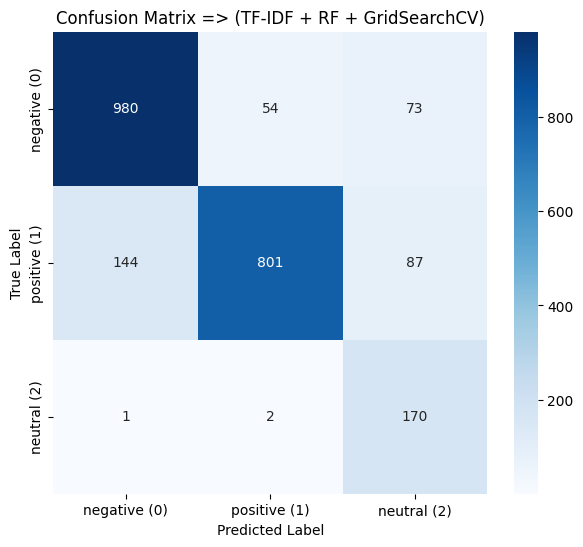

In [29]:
cm_best = confusion_matrix(y_test, y_pred_grid)

plt.figure(figsize=(7,6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative (0)', 'positive (1)', 'neutral (2)'],
            yticklabels=['negative (0)', 'positive (1)', 'neutral (2)']
            )

plt.title('Confusion Matrix => (TF-IDF + RF + GridSearchCV)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

<div align="center">Bar Chart :نمودار مقایسه ای</div>

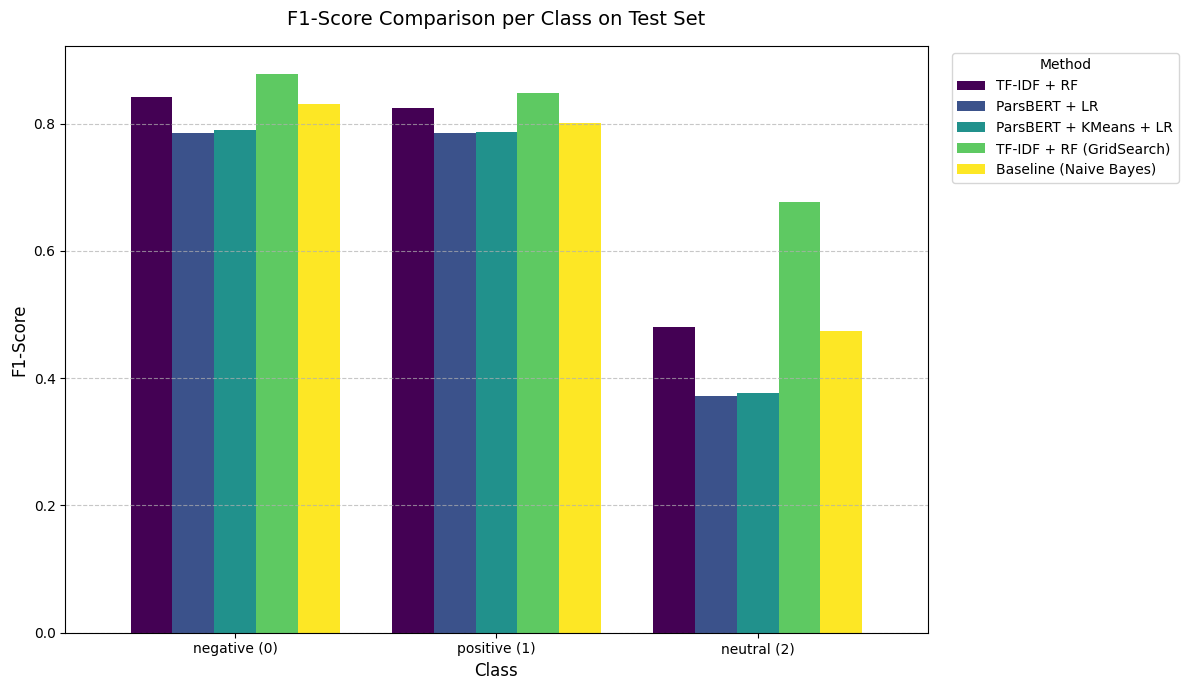

In [30]:
f1_per_class = pd.DataFrame({
    'Class': ['negative (0)', 'positive (1)', 'neutral (2)'],
    'TF-IDF + RF': f1_score(y_test, y_pred_tfidf, average=None),
    'ParsBERT + LR': f1_score(y_test, y_pred_parsbert, average=None),
    'ParsBERT + KMeans + LR': f1_score(y_test, y_pred_clustered, average=None),
    'TF-IDF + RF (GridSearch)': f1_score(y_test, y_pred_grid, average=None),
    'Baseline (Naive Bayes)': f1_score(y_test, y_pred_mnb, average=None)
})

f1_per_class.plot(
    x='Class',
    kind='bar',
    figsize=(12, 7),
    rot=0,
    width=0.8,
    colormap='viridis'
)

plt.title('F1-Score Comparison per Class on Test Set', fontsize=14, pad=15)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Class', fontsize=12)
plt.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()